## 1. Estructura inicial de carpetas y archivos

- En este proyecto dummy, va a ser una API Rest de servidor, con dependencia **'Express'**, modulos de **'Users'**,**'Products'** y **'Sales'**, y con **'MongoDB'** como BD para la persistencia de datos.

- Estructura de carpetas y archivos:

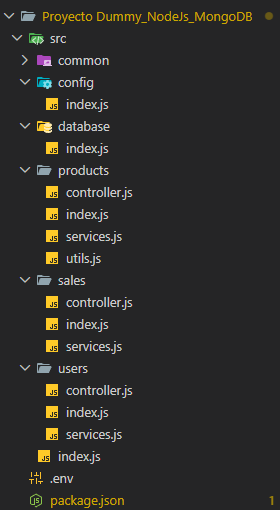

## 2. Instalar dependencias necesarias
- Primero asegurar q el path en la terminal sea el de la carpeta general del proyecto.
- Iniciar proyecto con Node -> `pnpm init`
- Instalar dependencias -> `pnpm install mongodb`,`pnpm i express`, `pnpm i http-errors` , `pnpm i dotenv`,
`pnpm i debug` , `pnpm i excel4node`
- Instalar dependencias de desarrollo -> `pnpm i -D nodemon`
- Si no ha habido fallos, las dependencias se han instalado correctamente y se reflejan en el package.json.
- En el objetos `"script` del package.json, modificar/añadir una clave : valor para el nodemon, en el valor establecer el path relativo de nuestro index.js o sobre el js que queramos que el servidor esté constantemente escuchando.  
En este caso: 

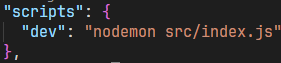

Es decir; nodemon sobre el index principal en la ruta src del proyecto.  
Para iniciar la devDependency 'nodemon', en terminal(asegurarse de estar en el path correcto) -> `pnpm run dev`


## 3. Index.js Principal

1. Importamos y guardamos las dependencias en variables  
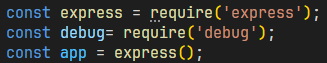

2. Middleware  
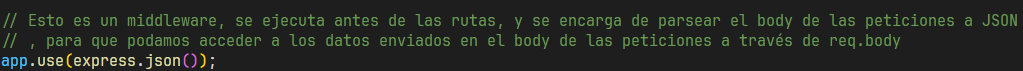

3. El archivo `.env`  
Gestiona configuraciones de entorno y variables sensibles de forma segura y organizada.  
Su función principal es separar la configuración (que cambia según donde se ejecute la aplicación) del código fuente (que debe permanecer igual).  
Indispensable en entornos de producción, donde existen claves/contraseñas, conexión real a una BD.  
Con la libreria `dotenv` podemos usar metodos para usar las variables de .env en nuestro `index.js de la carpeta config`.  
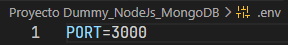  
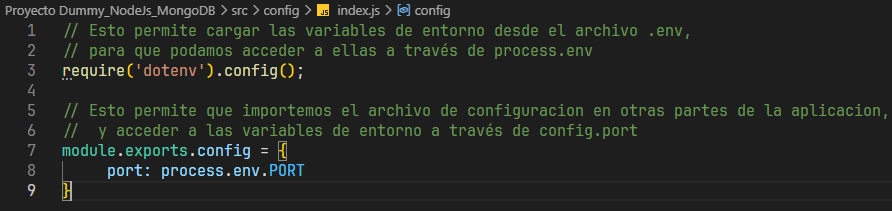

4. Refactorizar  
Con el `config` exportado, podemos desestructurar el objeto `config` y usar la variable PORT. Esta es la manera profesional
y segura de hacerlo.  
Al cambiar el puerto hardcodeado a la variable del env, el nodemon confirma la inyección de la variable si todo fue bien  
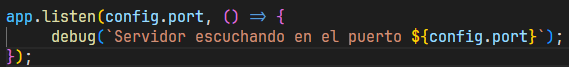  
  
- *TIP*: Al desestructurar un objeto, creamos un const, abrimos llaves y dentro ponemos el objeto a desestructurar. Para hacerlo de manera segura, poner el cursor entre las llaves, ctrl + espacio, y aparecerá los objetos que hayamos exportado,
de momento solo uno, `config`.  
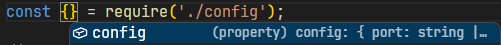



## 4. Base de Datos

1. Este index.js se va a encargar de exportar una funcion q nos devuelva la conexión con la base de datos Mongo.
A partir de ahí, poder trabajar con esa conexión.

2. Generamos la conexión con MongoDB  
Generando un `require()` en el cual pasamos la depedencia mongo (en el argumento escribir mo y ctrl + espacio para seleccionarlo).  
El require se guarda en una const en la q desestructurar `{ MongoClient }`  
  
Esto importa la clase MongoClient de la dependencia.

- `const debug = require("debug")("app:module-database");`  
Esta linea importa el debug. Se usa para mostrar mensajes de depuración/información de código.

- `let connection = null;`  
Variable que guardará la conexión de cliente con MongoDB

- `module.exports.Database = (collection) => new Promise(async (resolve, reject) => { ... });`  
Esto exporta una funcion llamada `Database`.  
La funcion toma como argumento una `collection` q retorna una `Promise`.  
Este diseño asincrono es el standard de operaciones que involucren Inputs/Outputs, como la conexión a una base de datos.

- Dentro de la Promise  

     - `try { ... } catch (error) { reject(error) }`:  
     La logica de la conexion esta envuelta en un try catch para el manejo de errores. Si ocurre el error, la `Promise` será rechazada.

     - `if (!connection) { ... }`  
     Si no hay conexión...  

     - `const client = new MongoClient();`  
     Una nueva instancia de MongoClient() es creada, en la variable client

     - `connection = await client.connect();`  
     El metodo `connect()` es llamado sobre el cliente para establecer una conexion con el servidor de MongoDB. Esta es una operación asincrona, por lo q se usa `await`

     - `debug('Nueva conexion realizada con MongoDB')`  
     Un mensaje informatico de debug

     - Fuera del codigo de `if`  
          - `const db = connection.db()`  
          Si la conexion existía de antes o se ha creado, esta linea recoge la instancia del `client` conectado 

          - `resolve(db.collection(collection))`  
          La `Promise` es resuelta con la `collection` especificada desde la base de datos 

3. Variable de entorno en `.env`  
- En MongoDb Atlas, en el proyecto, pinchar en *Connect*, y aparecera una **connection string** que deberemos usar. Esa strign se le conoce como `URI`.  
Ese string es importante, contiene el usuario y la contraseña con la q conectamos a Mongo, por tanto la usamos como variable de entorno.  
En el `.env` guardamos en una variable esa cadena (el db_password hay q cambiarlo con el q tengamos en el usuario enmongo atlas )  


- En el index de config, añadir los process.env de las variables de entorno  
 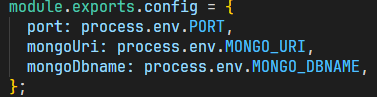

- En el index de database:  
     - desestructurar el config  
       
     - Pasamos como argumento el config desestructurado con la variable de entorno uri a la instancia de new MongoClient()  
       
     - Y en la linea q establece la conexión a la db, la variable de entorno mongoDbname  
     